In [1]:
!pip install --upgrade xee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 478.0/478.0 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.3 MB/s eta 0:00:00
  Attempting uninstall: earthengine-api
    Found existing installation: earthengine-api 1.5.24
    Uninstalling earthengine-api-1.5.24:
      Successfully uninstalled earthengine-api-1.5.24


In [2]:
!pip install -U geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 80.8 MB/s eta 0:00:00
  Attempting uninstall: geemap
    Found existing installation: geemap 0.35.3
    Uninstalling geemap-0.35.3:
      Successfully uninstalled geemap-0.35.3


In [3]:
import ee

In [4]:
ee.Authenticate()
ee.Initialize(project = "ee-grmntfrancis0",
              opt_url='https://earthengine-highvolume.googleapis.com')

In [5]:
import geemap

In [104]:
map = geemap.Map()
map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [106]:
roi = map.draw_last_feature.geometry()
roi

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Feature.geometry",
    "arguments": {
      "feature": {
        "functionInvocationValue": {
          "functionName": "Feature",
          "arguments": {
            "geometry": {
              "functionInvocationValue": {
                "functionName": "GeometryConstructors.Polygon",
                "arguments": {
                  "coordinates": {
                    "constantValue": [
                      [
                        [
                          -168.04619,
                          -78.906044
                        ],
                        [
                          -168.04619,
                          72.812828
                        ],
                        [
                          192.652183,
                          72.812828
                        ],
                        [
                          192.652183,
                          -78.906044
                        ],
                        [
                          -168.04619,
                          -78.906044
                        ]
                      ]
                    ]
                  },
                  "geodesic": {
                    "constantValue": false
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})

In [107]:
pdsi = (ee.ImageCollection("IDAHO_EPSCOR/TERRACLIMATE")
.filterDate("2000", "2026")
.select("pdsi")
.mean()
)

pdsi

In [108]:
import xarray as xr

In [109]:
ds = xr.open_dataset(
    pdsi,
    engine = "ee",
    crs = "EPSG:4326",
    geometry = roi,
    scale = 1

)

ds

<xarray.Dataset> Size: 223kB
Dimensions:  (time: 1, lon: 360, lat: 152)
Coordinates:
  * time     (time) int64 8B 0
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 1kB -78.41 -77.41 -76.41 -75.41 ... 70.59 71.59 72.59
Data variables:
    pdsi     (time, lon, lat) float32 219kB ...
Attributes:
    crs:      EPSG:4326

In [110]:
ds = ds.squeeze('time').drop_vars('time') * 0.01

In [111]:
ds

<xarray.Dataset> Size: 223kB
Dimensions:  (lon: 360, lat: 152)
Coordinates:
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 1kB -78.41 -77.41 -76.41 -75.41 ... 70.59 71.59 72.59
Data variables:
    pdsi     (lon, lat) float32 219kB nan nan nan nan nan ... nan nan -4.333 nan
Attributes:
    crs:      EPSG:4326

In [112]:
!pip install cartopy

In [113]:
import cartopy.crs as ccrs

In [114]:
import matplotlib.pyplot as plt

In [115]:
ds

<xarray.Dataset> Size: 223kB
Dimensions:  (lon: 360, lat: 152)
Coordinates:
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 1kB -78.41 -77.41 -76.41 -75.41 ... 70.59 71.59 72.59
Data variables:
    pdsi     (lon, lat) float32 219kB nan nan nan nan nan ... nan nan -4.333 nan
Attributes:
    crs:      EPSG:4326

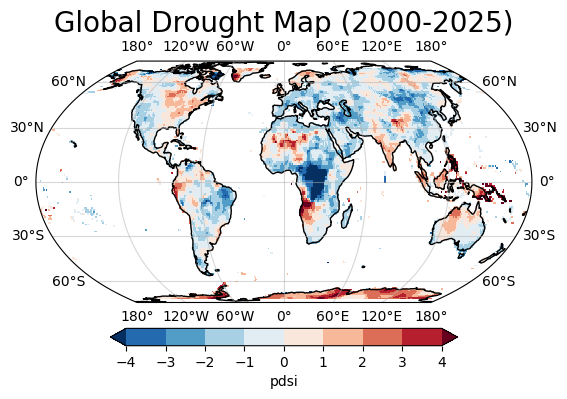

In [140]:
plt.figure()
ax = plt.axes(projection = ccrs.EqualEarth())
ax.coastlines(resolution = "110m")
ax.set_global()
ds.pdsi.plot(
    x = "lon", y = "lat", transform = ccrs.PlateCarree(),
   robust = True, cmap = "RdBu_r", levels = 10,
    cbar_kwargs = {
        "orientation": "horizontal", "pad": 0.07, "shrink": 0.7
    }
)
ax.gridlines(draw_labels = True, alpha = 0.5)
ax.set_title("Global Drought Map (2000-2025)", fontsize = 20)
plt.savefig("drought_map.png", dpi = 360, bbox_inches = "tight")
